# Estimating Covariance and Expected Returns

We’ve backtested cap-weighted (CW) and equal-weighted (EW) portfolios as baseline implementations.

CW portfolios are widely used in practice because they are inexpensive to implement, have low turnover, and represent a market-average allocation.

EW portfolios are a natural alternative and a simple improvement in some settings. Like CW, they require no explicit estimation of expected returns or covariance, and they are easy to construct.

Next, we move to more sophisticated portfolio construction methods that rely on estimating expected returns and covariance—so we begin by loading the data and re-creating the CW and EW baselines for comparison.


In [1]:
import numpy as np
import pandas as pd

import risk_kit as rk

%load_ext autoreload
%autoreload 2

In [3]:
inds = ['Food', 'Beer', 'Smoke', 'Games', 'Books', 'Hshld', 'Clths', 'Hlth',
       'Chems', 'Txtls', 'Cnstr', 'Steel', 'FabPr', 'ElcEq', 'Autos', 'Carry',
       'Mines', 'Coal', 'Oil', 'Util', 'Telcm', 'Servs', 'BusEq', 'Paper',
       'Trans', 'Whlsl', 'Rtail', 'Meals', 'Fin', 'Other']
#inds=['Beer', 'Hlth', 'Fin','Rtail','Whlsl']
ind_rets = rk.get_ind_returns(weighting="ew", n_inds=49)["1974":]
ind_mcap = rk.get_ind_market_caps(49, weights=True)["1974":]

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.131606,0.187437,-0.616296,6.771301,0.082035,0.122226,0.527384,-0.598060
CW,0.132950,0.192736,-0.493055,5.997952,0.083575,0.124111,0.519656,-0.584692


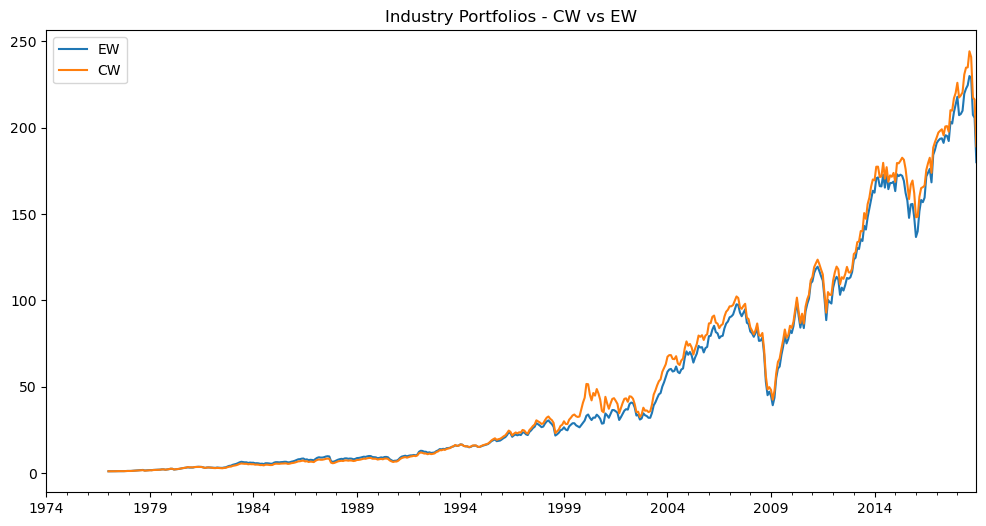

In [4]:
ewr = rk.backtest_ws(ind_rets, estimation_window=36, weighting=rk.weight_ew)
cwr = rk.backtest_ws(ind_rets, estimation_window=36, weighting=rk.weight_cw, cap_weights=ind_mcap)
btr = pd.DataFrame({"EW": ewr, "CW": cwr})
(1+btr).cumprod().plot(figsize=(12,6), title="Industry Portfolios - CW vs EW")
rk.summary_stats(btr.dropna())

# Building the Global Minimum Variance Portfolio


In [6]:
def sample_cov(r, **kwargs):
    """
    Returns the sample covariance of the supplied returns
    """
    return r.cov()

def weight_gmv(r, cov_estimator=sample_cov, **kwargs):
    """
    Produces the weights of the GMV portfolio given a covariance matrix of the returns 
    """
    est_cov = cov_estimator(r, **kwargs)
    return rk.gmv(est_cov)

Now, let's run this new backtest. We are running a backtest over nearly 50 years and both optimizing and rebalancing on a monthly basis.

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.131606,0.187437,-0.616296,6.771301,0.082035,0.122226,0.527384,-0.598060
CW,0.132950,0.192736,-0.493055,5.997952,0.083575,0.124111,0.519656,-0.584692
GMV-Sample,0.153094,0.116303,-0.811386,6.408528,0.047674,0.072557,1.030064,-0.463914


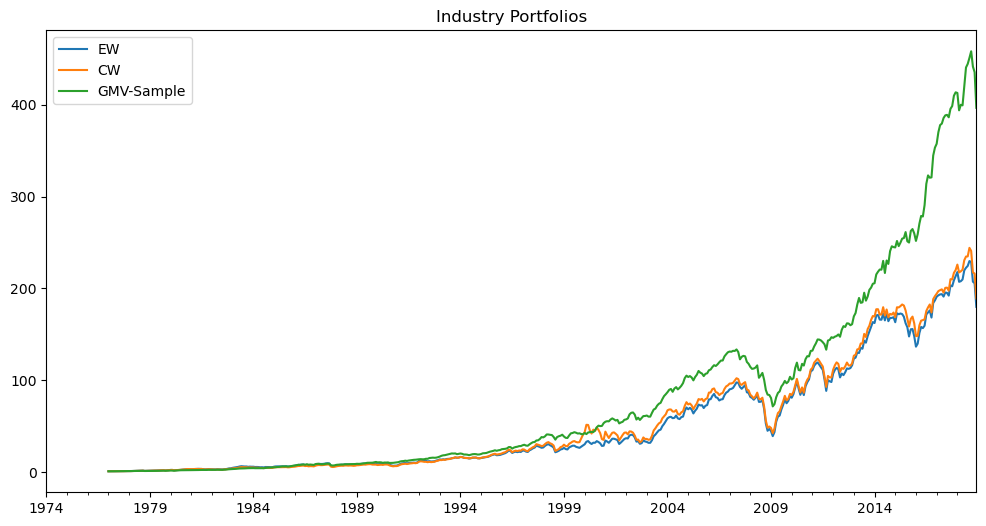

In [7]:
mv_s_r = rk.backtest_ws(ind_rets, estimation_window=36, weighting=weight_gmv, cov_estimator=sample_cov)
btr = pd.DataFrame({"EW": ewr, "CW": cwr, "GMV-Sample": mv_s_r})
(1+btr).cumprod().plot(figsize=(12,6), title="Industry Portfolios")
rk.summary_stats(btr.dropna())

Constant Correlation. The idea is to take the sample correlation matrix, compute the average correlation and then reconstruct the covariance matrix. The relation between correlations $\rho$ and covariance $\sigma$ is given by:

$$ \rho_{ij} = \frac{ \sigma_{ij} } { \sqrt{ \sigma_{ii}  \sigma_{jj} } } $$

In [8]:
#import statsmodels.stats.moment_helpers as mh
def cc_cov(r, **kwargs):
    """
    Estimates a covariance matrix by using the Elton/Gruber Constant Correlation model
    """
    rhos = r.corr()
    n = rhos.shape[0]
    # this is a symmetric matrix with diagonals all 1 
    rho_bar = (rhos.values.sum()-n)/(n*(n-1))
    ccor = np.full_like(rhos, rho_bar)
    np.fill_diagonal(ccor, 1.)
    sd = r.std()
    ccov = ccor * np.outer(sd, sd)
#     mh.corr2cov(ccor, sd)
    return pd.DataFrame(ccov, index=r.columns, columns=r.columns)

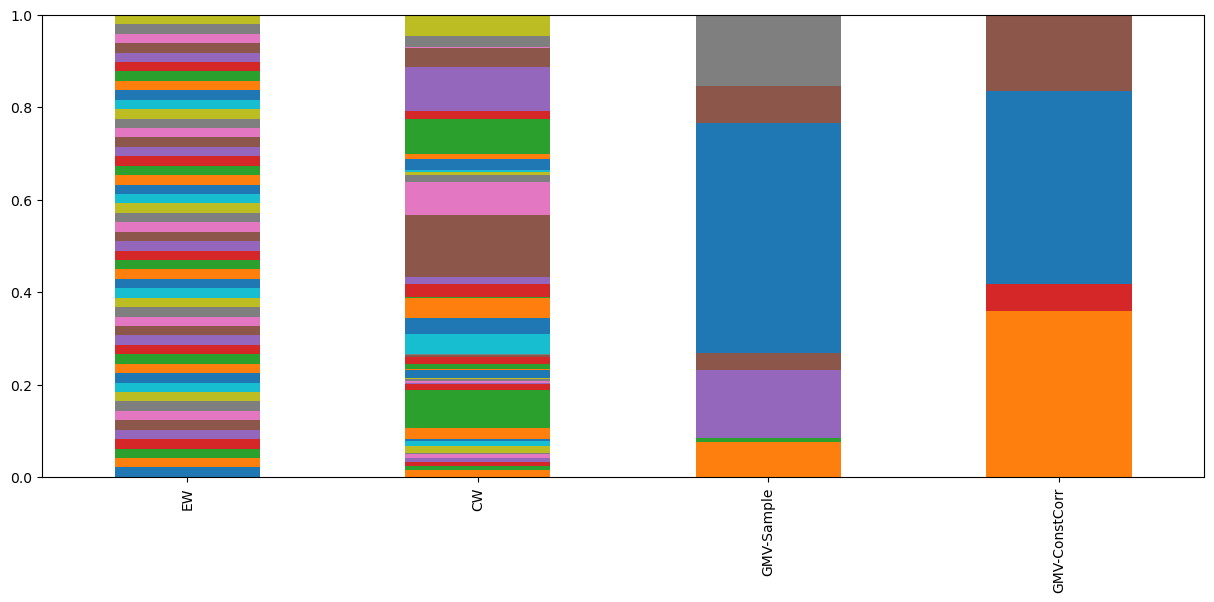

In [9]:
wts = pd.DataFrame({
    "EW": rk.weight_ew(ind_rets["2016":]),
    "CW": rk.weight_cw(ind_rets["2016":], cap_weights=ind_mcap),
    "GMV-Sample": rk.weight_gmv(ind_rets["2016":], cov_estimator=sample_cov),
    "GMV-ConstCorr": rk.weight_gmv(ind_rets["2016":], cov_estimator=cc_cov),
})
wts.T.plot.bar(stacked=True, figsize=(15,6), legend=False);

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.131606,0.187437,-0.616296,6.771301,0.082035,0.122226,0.527384,-0.598060
CW,0.132950,0.192736,-0.493055,5.997952,0.083575,0.124111,0.519656,-0.584692
GMV-Sample,0.153094,0.116303,-0.811386,6.408528,0.047674,0.072557,1.030064,-0.463914
GMV-CC,0.132373,0.115348,-0.890930,6.072369,0.049609,0.075268,0.863725,-0.524087


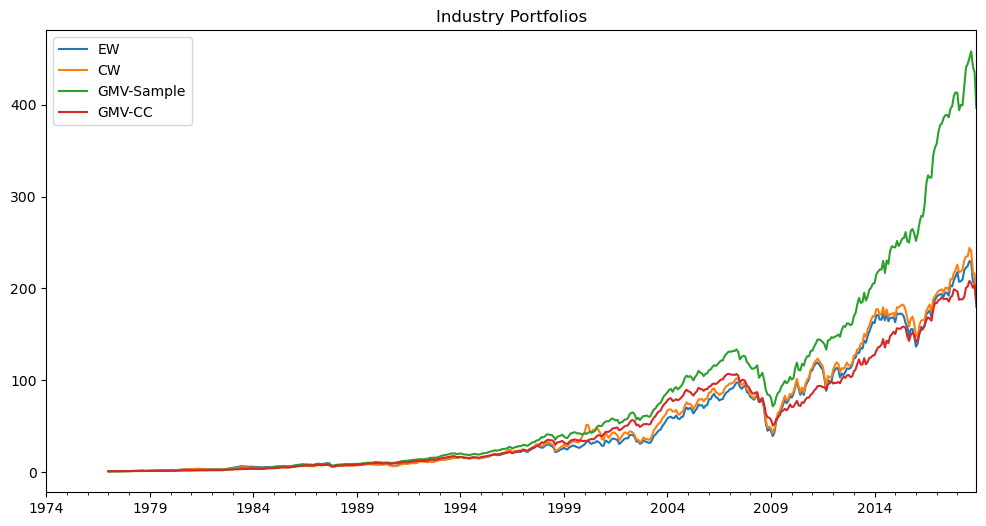

In [10]:
mv_cc_r = rk.backtest_ws(ind_rets, estimation_window=36, weighting=weight_gmv, cov_estimator=cc_cov)
btr = pd.DataFrame({"EW": ewr, "CW": cwr, "GMV-Sample": mv_s_r, "GMV-CC": mv_cc_r})
(1+btr).cumprod().plot(figsize=(12,6), title="Industry Portfolios")
rk.summary_stats(btr.dropna())

### Statistical Shrinkage

We can mix the model and sample estimates by choosing a shrinkage parameter. You can either let the numbers dictate an optimal shrinkage value for $\delta$ although in practice many practiotioners choose $0.5$. Let's implement a simple shrinkage based covariance estimator that shrinks towards the Constant Correlation estimate.

In [11]:
def shrinkage_cov(r, delta=0.5, **kwargs):
    """
    Covariance estimator that shrinks between the Sample Covariance and the Constant Correlation Estimators
    """
    prior = cc_cov(r, **kwargs)
    sample = sample_cov(r, **kwargs)
    return delta*prior + (1-delta)*sample

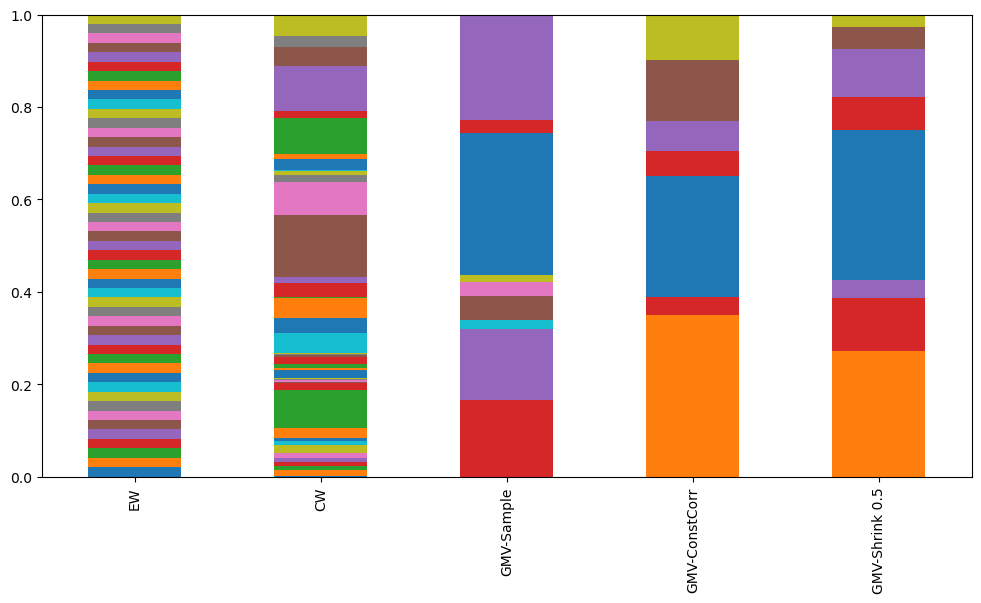

In [12]:
wts = pd.DataFrame({
    "EW": rk.weight_ew(ind_rets["2013":]),
    "CW": rk.weight_cw(ind_rets["2013":], cap_weights=ind_mcap),
    "GMV-Sample": rk.weight_gmv(ind_rets["2013":], cov_estimator=sample_cov),
    "GMV-ConstCorr": rk.weight_gmv(ind_rets["2013":], cov_estimator=cc_cov),
    "GMV-Shrink 0.5": rk.weight_gmv(ind_rets["2013":], cov_estimator=shrinkage_cov),
})
wts.T.plot.bar(stacked=True, figsize=(12,6), legend=False);

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
EW,0.131606,0.187437,-0.616296,6.771301,0.082035,0.122226,0.527384,-0.598060
CW,0.132950,0.192736,-0.493055,5.997952,0.083575,0.124111,0.519656,-0.584692
GMV-Sample,0.153094,0.116303,-0.811386,6.408528,0.047674,0.072557,1.030064,-0.463914
GMV-CC,0.132373,0.115348,-0.890930,6.072369,0.049609,0.075268,0.863725,-0.524087
GMV-Shrink 0.5,0.138498,0.114873,-0.886361,6.305896,0.048716,0.074239,0.919203,-0.518470


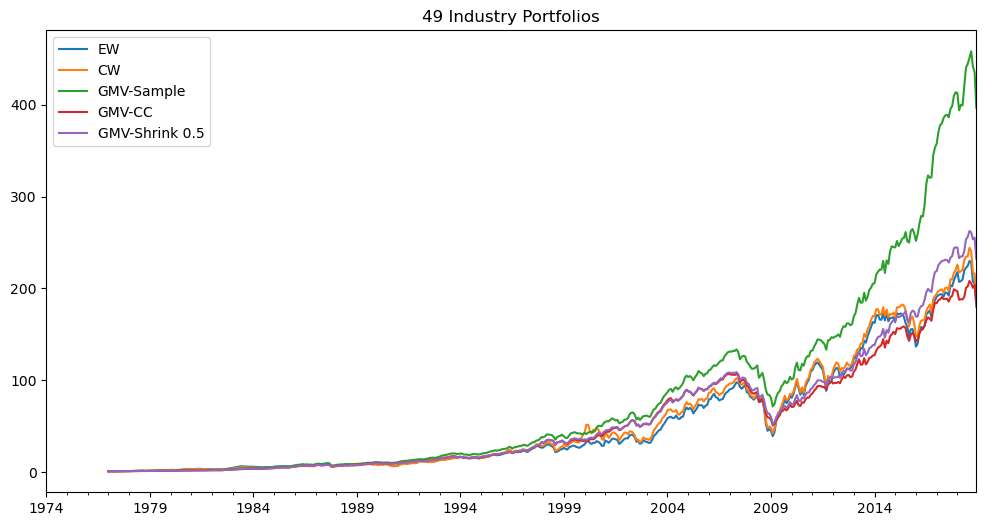

In [13]:
mv_sh_r = rk.backtest_ws(ind_rets, estimation_window=36, weighting=weight_gmv, cov_estimator=shrinkage_cov, delta=0.5)
btr = pd.DataFrame({"EW": ewr, "CW": cwr, "GMV-Sample": mv_s_r, "GMV-CC": mv_cc_r, 'GMV-Shrink 0.5': mv_sh_r})
(1+btr).cumprod().plot(figsize=(12,6), title="49 Industry Portfolios")
rk.summary_stats(btr.dropna())